In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Opt_model import build_model, build_chance_constrained_model

In [2]:
# Load Data
file_path = "D:\\3. study at TUD\\SoSe 25\\7. Gurobi\\NERD_case_data.xlsx"

rdc_demand_df      = pd.read_excel(file_path, sheet_name="RDC_Demand",
                                   na_values=[], keep_default_na=False)
dc_capacity_df     = pd.read_excel(file_path, sheet_name="DC_Capacity",
                                   na_values=[], keep_default_na=False)
dc_costs_df        = pd.read_excel(file_path, sheet_name="DC_Costs",
                                   na_values=[], keep_default_na=False)
plant_var_cost_df  = pd.read_excel(file_path, sheet_name="Plant_Var_Costs",
                                   na_values=[], keep_default_na=False)
inbound_cost_df    = pd.read_excel(file_path, sheet_name="IB_Costs",
                                   na_values=[], keep_default_na=False)
outbound_cost_df   = pd.read_excel(file_path, sheet_name="OB_Costs",
                                   na_values=[], keep_default_na=False)

display(rdc_demand_df)
display(dc_capacity_df)
display(dc_costs_df)

,RDC,Demand_bl_per_week
0,BO,450
1,BR,60
2,CO,80
3,HA,130
4,MN,110
5,NA,140
6,NH,140
7,NL,70
8,PO,120
9,PR,310


,DC,DC Cap
0,BO,1000
1,NA,500
2,PR,1000
3,SP,500
4,WO,1000


,DC,Var Cost,Fixed Cost
0,BO,1.50,11000
1,NA,0.95,5000
2,PR,1.05,9000
3,SP,1.10,8000
4,WO,1.12,7000


In [3]:
# Build Dictionaries
rdc_demand     = dict(zip(rdc_demand_df['RDC'],
                          rdc_demand_df['Demand_bl_per_week']))
dc_capacity    = dict(zip(dc_capacity_df['DC'],
                          dc_capacity_df['DC Cap']))
dc_fixed_cost  = dict(zip(dc_costs_df['DC'],
                          dc_costs_df['Fixed Cost']))
dc_var_cost    = dict(zip(dc_costs_df['DC'],
                          dc_costs_df['Var Cost']))
plant_var_cost = dict(zip(plant_var_cost_df['Plant'],
                          plant_var_cost_df['Var Cost']))

inbound_cost = {}
for _, row in inbound_cost_df.iterrows():
    dc = row['DC']
    inbound_cost[('BFP', dc)] = row['BFP']
    inbound_cost[('SCP', dc)] = row['SCP']

outbound_cost = {}
for _, row in outbound_cost_df.iterrows():
    dc = row['DC']
    for rdc in outbound_cost_df.columns[1:]:
        outbound_cost[(dc, rdc)] = row[rdc]

plants = ['BFP', 'SCP']
dcs    = list(dc_capacity.keys())
rdcs   = list(rdc_demand.keys())
print(f"Plants: {plants}\nDCs: {dcs}\nRDCs: {rdcs}")

Plants: ['BFP', 'SCP']
DCs: ['BO', 'NA', 'PR', 'SP', 'WO']
RDCs: ['BO', 'BR', 'CO', 'HA', 'MN', 'NA', 'NH', 'NL', 'PO', 'PR', 'SP', 'WO']


In [4]:
# Solve Deterministic Model
det_model, x_det, y_det, z_det = build_model(
    plants, dcs, rdcs,
    rdc_demand, dc_capacity, dc_fixed_cost, dc_var_cost,
    plant_var_cost, inbound_cost, outbound_cost
)
det_model.optimize()

if det_model.status == 2:
    print(f"Deterministic Total Cost: {det_model.ObjVal:,.2f}")
    fixed_det    = sum(dc_fixed_cost[i] * y_det[i].X for i in dcs)
    inbound_det  = sum((plant_var_cost[p] + inbound_cost[(p, i)]) * z_det[p, i].X
                       for p in plants for i in dcs)
    outbound_det = sum((dc_var_cost[i] + outbound_cost[(i, j)]) * x_det[i, j].X
                       for i in dcs for j in rdcs)
    print(f"Fixed: {fixed_det:,.2f} | Inbound: {inbound_det:,.2f} "
          f"| Outbound: {outbound_det:,.2f}")
    print("Opened DCs:", [i for i in dcs if y_det[i].X > 0.5])

Set parameter Username
Set parameter LicenseID to value 2826522
Academic license - for non-commercial use only - expires 2027-05-22
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-11800H @ 2.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 22 rows, 75 columns and 195 nonzeros
Model fingerprint: 0x84e23342
Variable types: 70 continuous, 5 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [5e+00, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [6e+01, 5e+02]
Presolve removed 5 rows and 10 columns
Presolve time: 0.00s
Presolved: 17 rows, 65 columns, 125 nonzeros
Variable types: 60 continuous, 5 integer (5 binary)
Found heuristic solution: objective 78524.400000

Root relaxation: objective 6.087260e+04, 7 iterations, 0.00 sec

In [11]:
# Generate Demand Scenarios
NUM_SCENARIOS  = 100
STD_DEV_FACTOR = 0.15
RANDOM_SEED    = 42
np.random.seed(RANDOM_SEED)

demand_scenarios = []
for s in range(NUM_SCENARIOS):
    scenario = {}
    for j in rdcs:
        mean      = rdc_demand[j]
        std       = STD_DEV_FACTOR * mean
        raw_value = np.random.normal(loc=mean, scale=std)
        scenario[j] = max(0.0, raw_value)   # truncate at 0
    demand_scenarios.append(scenario)

# Summary table
stats = []
for j in rdcs:
    vals = [demand_scenarios[s][j] for s in range(NUM_SCENARIOS)]
    stats.append({'RDC': j, 'Base': rdc_demand[j],
                  'Mean': np.mean(vals), 'Std': np.std(vals),
                  'Min': np.min(vals),   'Max': np.max(vals)})
display(pd.DataFrame(stats).round(2))

,RDC,Base,Mean,Std,Min,Max
0,BO,450,456.43,56.64,309.47,612.23
1,BR,60,59.12,8.64,42.36,81.96
2,CO,80,80.07,11.85,48.56,109.35
3,HA,130,131.67,18.15,85.11,171.77
4,MN,110,110.26,15.89,69.22,151.69
5,NA,140,145.18,22.79,80.18,220.91
6,NH,140,144.29,19.31,104.23,194.04
7,NL,70,70.01,10.49,48.56,95.78
8,PO,120,120.30,17.84,72.28,158.39
9,PR,310,305.03,46.11,175.32,416.53


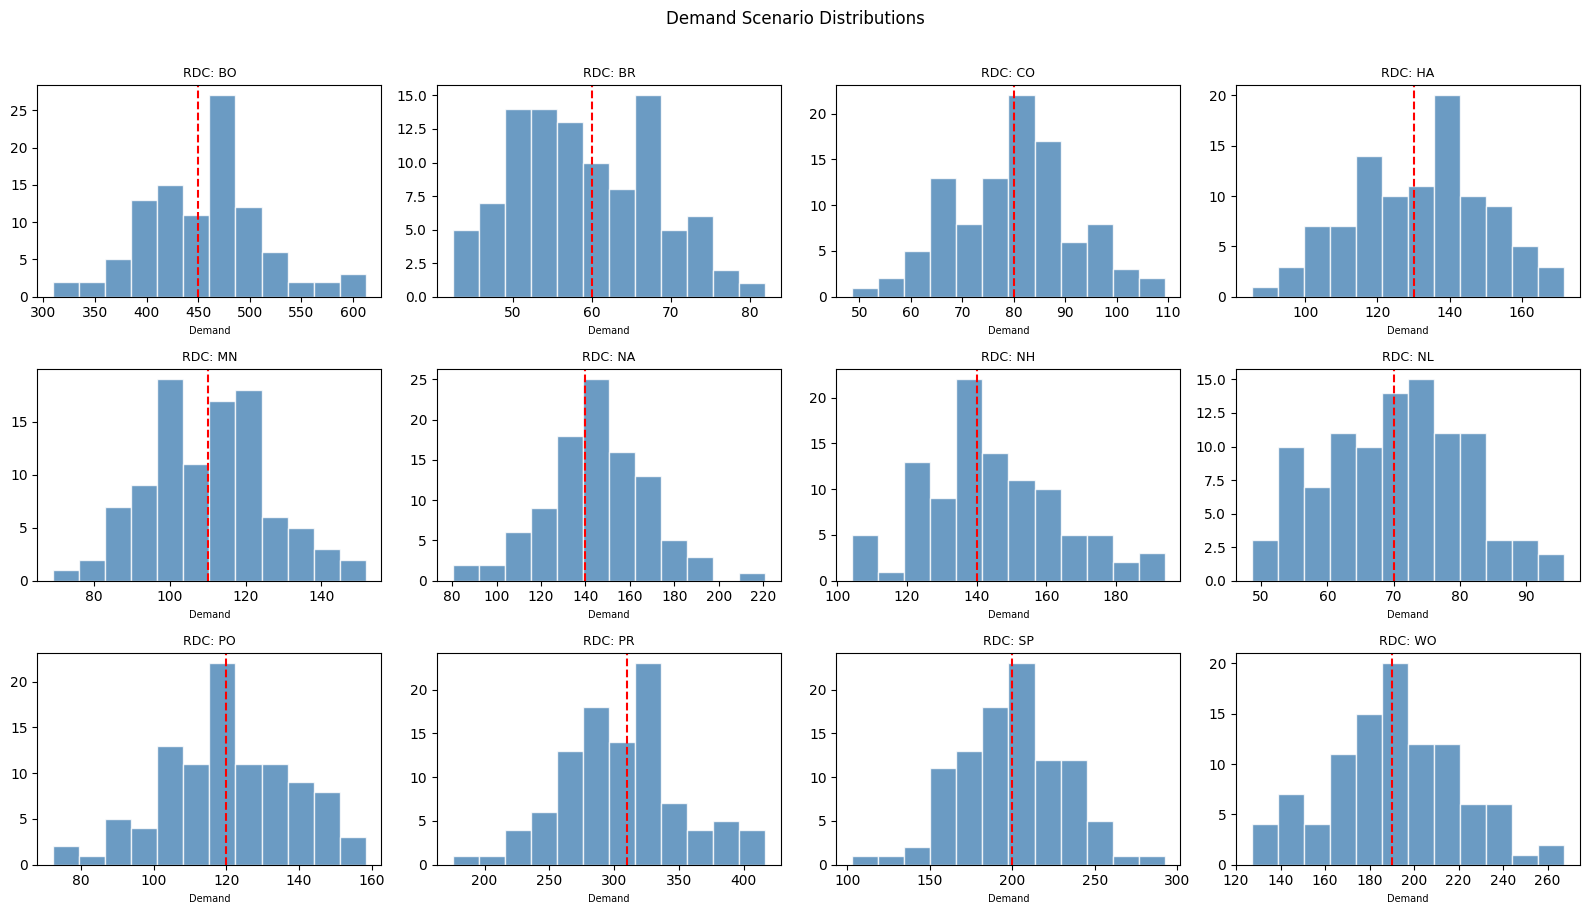

In [12]:
# Plot Scenario Distributions
fig, axes = plt.subplots(
    nrows=(len(rdcs) + 3) // 4, ncols=4,
    figsize=(16, 3 * ((len(rdcs) + 3) // 4))
)
axes = axes.flatten()
for idx, j in enumerate(rdcs):
    vals = [demand_scenarios[s][j] for s in range(NUM_SCENARIOS)]
    axes[idx].hist(vals, bins=12, color='steelblue',
                   edgecolor='white', alpha=0.8)
    axes[idx].axvline(rdc_demand[j], color='red',
                      linestyle='--', linewidth=1.5)
    axes[idx].set_title(f"RDC: {j}", fontsize=9)
    axes[idx].set_xlabel("Demand", fontsize=7)
for idx in range(len(rdcs), len(axes)):
    axes[idx].set_visible(False)
plt.suptitle("Demand Scenario Distributions", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Solve Chance-Constrained Model
SERVICE_LEVEL = 0.95

cc_model, x_cc, y_cc, z_cc, w_cc, slack_cc = build_chance_constrained_model(
    plants, dcs, rdcs,
    rdc_demand, demand_scenarios,
    dc_capacity, dc_fixed_cost, dc_var_cost,
    plant_var_cost, inbound_cost, outbound_cost,
    service_level=SERVICE_LEVEL
)
cc_model.optimize()

if cc_model.status == 2:
    print(f"CC Model Total Cost: {cc_model.ObjVal:,.2f}")
    print("Opened DCs:", [i for i in dcs if y_cc[i].X > 0.5])


  Chance-Constrained Model Configuration
  Number of scenarios  : 100
  Service level        : 95%
  Max allowed violations: 5 scenarios

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i7-11800H @ 2.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3401 rows, 8305 columns and 23200 nonzeros
Model fingerprint: 0x552d301d
Variable types: 8200 continuous, 105 integer (105 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [5e-02, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [5e+00, 6e+02]
Found heuristic solution: objective 115441.02788
Presolve removed 1700 rows and 2200 columns
Presolve time: 0.04s
Presolved: 1701 rows, 6105 columns, 13800 nonzeros
Found heuristic solution: objective 114930.59051
Variable types: 6000 continuous, 105 

In [14]:
# Scenario Analysis
scenarios      = list(range(NUM_SCENARIOS))
max_violations = int((1 - SERVICE_LEVEL) * NUM_SCENARIOS)
scenario_results = []

for s in scenarios:
    is_violated  = w_cc[s].X > 0.5
    total_demand = sum(demand_scenarios[s][j] for j in rdcs)
    total_deliv  = sum(x_cc[i, j, s].X for i in dcs for j in rdcs)
    total_slack  = sum(slack_cc[j, s].X for j in rdcs)
    scenario_results.append({
        'Scenario'       : s,
        'Violated'       : is_violated,
        'Total_Demand'   : round(total_demand, 1),
        'Total_Delivered': round(total_deliv,  1),
        'Total_Slack'    : round(total_slack,  2),
        'Fulfillment_Pct': round(100 * total_deliv / total_demand, 1)
                           if total_demand > 0 else 100.0
    })

results_df = pd.DataFrame(scenario_results)
display(results_df)

n_violated  = results_df['Violated'].sum()
n_satisfied = NUM_SCENARIOS - n_violated
print(f"\nSatisfied: {n_satisfied}/{NUM_SCENARIOS} "
      f"| Violated: {n_violated}/{NUM_SCENARIOS}")
print(f"Actual service level: {100*n_satisfied/NUM_SCENARIOS:.1f}% "
      f"(target: {SERVICE_LEVEL*100:.0f}%)")

,Scenario,Violated,Total_Demand,Total_Delivered,Total_Slack,Fulfillment_Pct
0,0,False,2091.8,2091.8,0.0,100.0
1,1,False,1900.7,1900.7,0.0,100.0
2,2,False,1889.0,1889.0,0.0,100.0
3,3,False,1950.8,1950.8,0.0,100.0
4,4,False,2045.1,2045.1,0.0,100.0
...,...,...,...,...,...,...
95,95,False,1850.5,1850.5,0.0,100.0
96,96,False,2010.5,2010.5,0.0,100.0
97,97,False,2133.6,2133.6,0.0,100.0
98,98,False,1876.5,1876.5,0.0,100.0



Satisfied: 95/100 | Violated: 5/100
Actual service level: 95.0% (target: 95%)


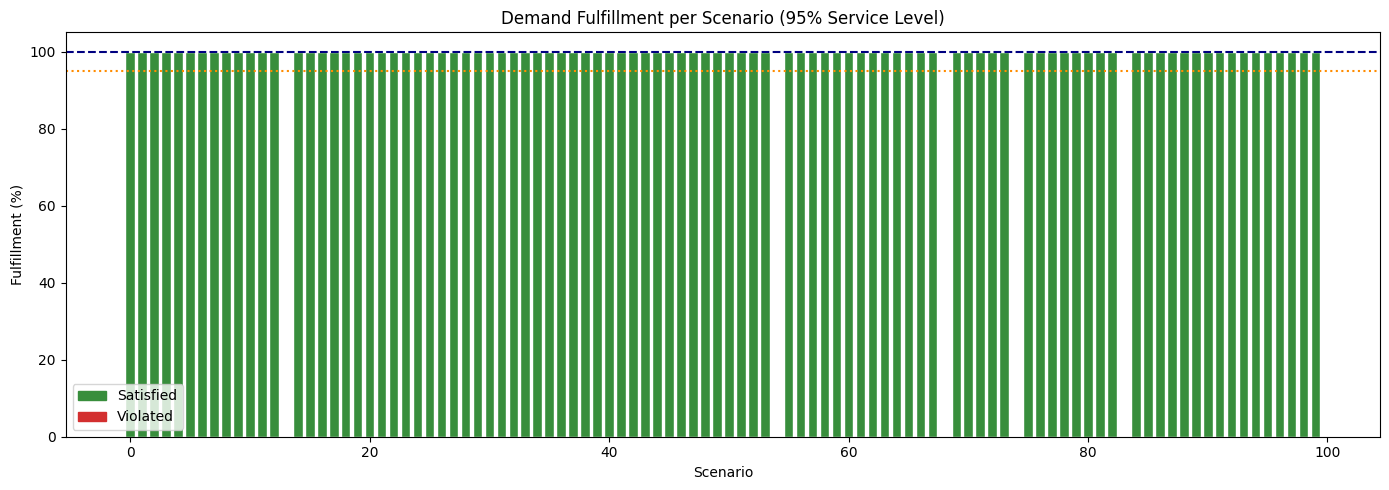

In [15]:
# Fulfillment Bar Chart
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#d32f2f' if r else '#388e3c' for r in results_df['Violated']]
ax.bar(results_df['Scenario'], results_df['Fulfillment_Pct'],
       color=colors, edgecolor='white')
ax.axhline(100,               color='navy',       linestyle='--', lw=1.5)
ax.axhline(SERVICE_LEVEL*100, color='darkorange', linestyle=':',  lw=1.5)
ax.set_xlabel('Scenario');  ax.set_ylabel('Fulfillment (%)')
ax.set_title('Demand Fulfillment per Scenario (95% Service Level)')
green_p = mpatches.Patch(color='#388e3c', label='Satisfied')
red_p   = mpatches.Patch(color='#d32f2f', label='Violated')
ax.legend(handles=[green_p, red_p])
plt.tight_layout(); plt.show()

,Model,Fixed,Inbound,Outbound,Total
0,Deterministic,20000.0,9825.00,38439.50,68264.50
1,Chance-Constrained,31000.0,9541.66,30661.51,71203.17


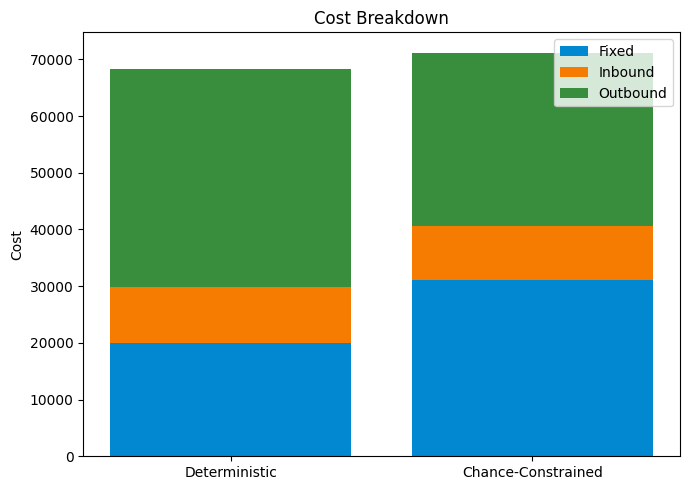

In [16]:
#  Cost Comparison
fixed_cc    = sum(dc_fixed_cost[i] * y_cc[i].X for i in dcs)
inbound_cc  = (1.0/NUM_SCENARIOS) * sum(
    (plant_var_cost[p] + inbound_cost[(p,i)]) * z_cc[p,i,s].X
    for p in plants for i in dcs for s in scenarios)
outbound_cc = (1.0/NUM_SCENARIOS) * sum(
    (dc_var_cost[i] + outbound_cost[(i,j)]) * x_cc[i,j,s].X
    for i in dcs for j in rdcs for s in scenarios)

cost_df = pd.DataFrame({
    'Model'  : ['Deterministic', 'Chance-Constrained'],
    'Fixed'  : [fixed_det,    fixed_cc],
    'Inbound': [inbound_det,  inbound_cc],
    'Outbound':[outbound_det, outbound_cc],
    'Total'  : [det_model.ObjVal, cc_model.ObjVal]
}).round(2)
display(cost_df)

# Stacked bar
fig, ax = plt.subplots(figsize=(7, 5))
x_pos = [0, 1]
ax.bar(x_pos, cost_df['Fixed'],   color='#0288d1', label='Fixed')
ax.bar(x_pos, cost_df['Inbound'], bottom=cost_df['Fixed'],
       color='#f57c00', label='Inbound')
ax.bar(x_pos, cost_df['Outbound'],
       bottom=cost_df['Fixed'] + cost_df['Inbound'],
       color='#388e3c', label='Outbound')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Deterministic', 'Chance-Constrained'])
ax.set_ylabel('Cost'); ax.set_title('Cost Breakdown')
ax.legend(); plt.tight_layout(); plt.show()